In [4]:
# Cell 1: Import tất cả các thư viện cần thiết
from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Cell 2: Cấu hình tham số hệ thống theo yêu cầu giảng viên
TRAIN_DIR = Path("../../TinHieuHuanLuyen")
TEST_DIR = Path("../../TinHieuKiemThu")
OUTPUT_DIR = Path("output/mine")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình DSP Frame 25 ms, Hop 10 ms, Lọc khoảng lặng ảo 200 ms
FRAME_TIME = 25
HOP_TIME = 10
MIN_SILENCE_MS = 200

# Cấu hình in số thực
np.set_printoptions(precision=6, suppress=True)


In [6]:
# Cell 3: Basic đọc dữ liệu WAV, tính STE
def read_wav(wav_file):
    with wave.open(str(wav_file), "rb") as audio:
        fs = audio.getframerate()
        channels = audio.getnchannels()
        sample_width = audio.getsampwidth()
        samples = audio.readframes(audio.getnframes())

    if sample_width != 2:
        raise ValueError("Yêu cầu định dạng âm thanh WAV 16-bit PCM")

    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    if channels > 1:
        signal = signal.reshape(-1, channels).mean(axis=1)

    return signal, fs


"""Chia tín hiệu thành các frame và tính Short-Time Energy (STE) chuẩn hóa."""
def calculate_ste(signal, fs, frame_ms=FRAME_TIME, hop_ms=HOP_TIME):
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    number_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    ste = np.zeros(number_frames)
    frame_starts = np.zeros(number_frames)

    for frame_index in range(number_frames):
        start = frame_index * hop_size
        end = start + frame_size
        frame = np.zeros(frame_size)
        available = signal[start:min(end, len(signal))]
        frame[:len(available)] = available

        ste[frame_index] = np.mean(frame ** 2)
        frame_starts[frame_index] = start / fs

    ste_norm = ste / max(float(np.max(ste)), 1e-12)
    return ste, ste_norm, frame_starts


=== THÔNG TIN TÍN HIỆU MẪU ===
Tên file:                  phone_F1.wav
Tần số lấy mẫu (fs):       16000 Hz
Số lượng mẫu:              51840
Thời lượng:                3.24 giây
Số lượng frame (25/10ms):  323
Biên độ gốc (min / max):   -28896.0 / 23918.0
Biên độ chuẩn hóa:         -1.0 / 0.8277


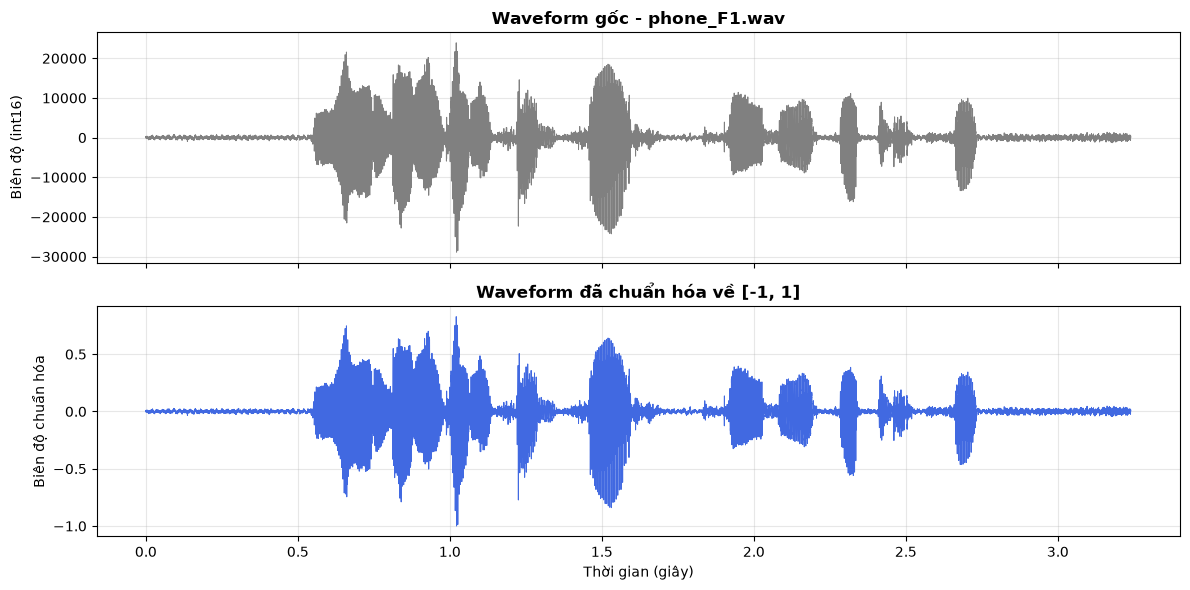

In [7]:
# Cell 3.5: Đọc và khảo sát 1 file WAV mẫu từ tập huấn luyện
train_wav_files = sorted(TRAIN_DIR.glob("*.wav"))
sample_file = train_wav_files[0]

sample_signal, sample_fs = read_wav(sample_file)
sample_signal_norm = sample_signal / np.max(np.abs(sample_signal))
sample_duration = len(sample_signal) / sample_fs
sample_ste, sample_ste_norm, sample_starts = calculate_ste(sample_signal_norm, sample_fs)

print("=== THÔNG TIN TÍN HIỆU MẪU ===")
print("Tên file:                 ", sample_file.name)
print("Tần số lấy mẫu (fs):      ", sample_fs, "Hz")
print("Số lượng mẫu:             ", len(sample_signal))
print("Thời lượng:               ", round(sample_duration, 4), "giây")
print("Số lượng frame (25/10ms): ", len(sample_ste_norm))
print("Biên độ gốc (min / max):  ", np.min(sample_signal), "/", np.max(sample_signal))
print("Biên độ chuẩn hóa:        ", round(float(np.min(sample_signal_norm)), 4), "/", round(float(np.max(sample_signal_norm)), 4))

# Vẽ đồ thị waveform gốc và waveform chuẩn hóa
sample_time = np.arange(len(sample_signal)) / sample_fs
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(sample_time, sample_signal, color="gray", linewidth=0.7)
axes[0].set_title(f"Waveform gốc - {sample_file.name}", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Biên độ (int16)")
axes[0].grid(alpha=0.3)

axes[1].plot(sample_time, sample_signal_norm, color="royalblue", linewidth=0.7)
axes[1].set_title("Waveform đã chuẩn hóa về [-1, 1]", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Thời gian (giây)")
axes[1].set_ylabel("Biên độ chuẩn hóa")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

                     BẢNG THỐNG KÊ CHI TIẾT TẬP HUẤN LUYỆN (TRAINING DATA)                      
File             | fs (Hz) | Tổng (s) | Frames | Biên Speech (s)   | Speech (s) | Tỉ lệ (%)
------------------------------------------------------------------------------------------------
phone_F1.wav     | 16000   | 3.240    | 323    | [0.53, 2.75]      | 2.220      | 68.52   %
phone_M1.wav     | 16000   | 4.160    | 415    | [0.46, 3.52]      | 3.060      | 73.56   %
studio_F1.wav    | 44100   | 2.863    | 285    | [0.68, 2.15]      | 1.470      | 51.34   %
studio_M1.wav    | 44100   | 2.730    | 272    | [0.87, 2.06]      | 1.190      | 43.59   %
Đã lưu ảnh đồ thị tập huấn luyện vào: output\mine\train_dataset_overview.png


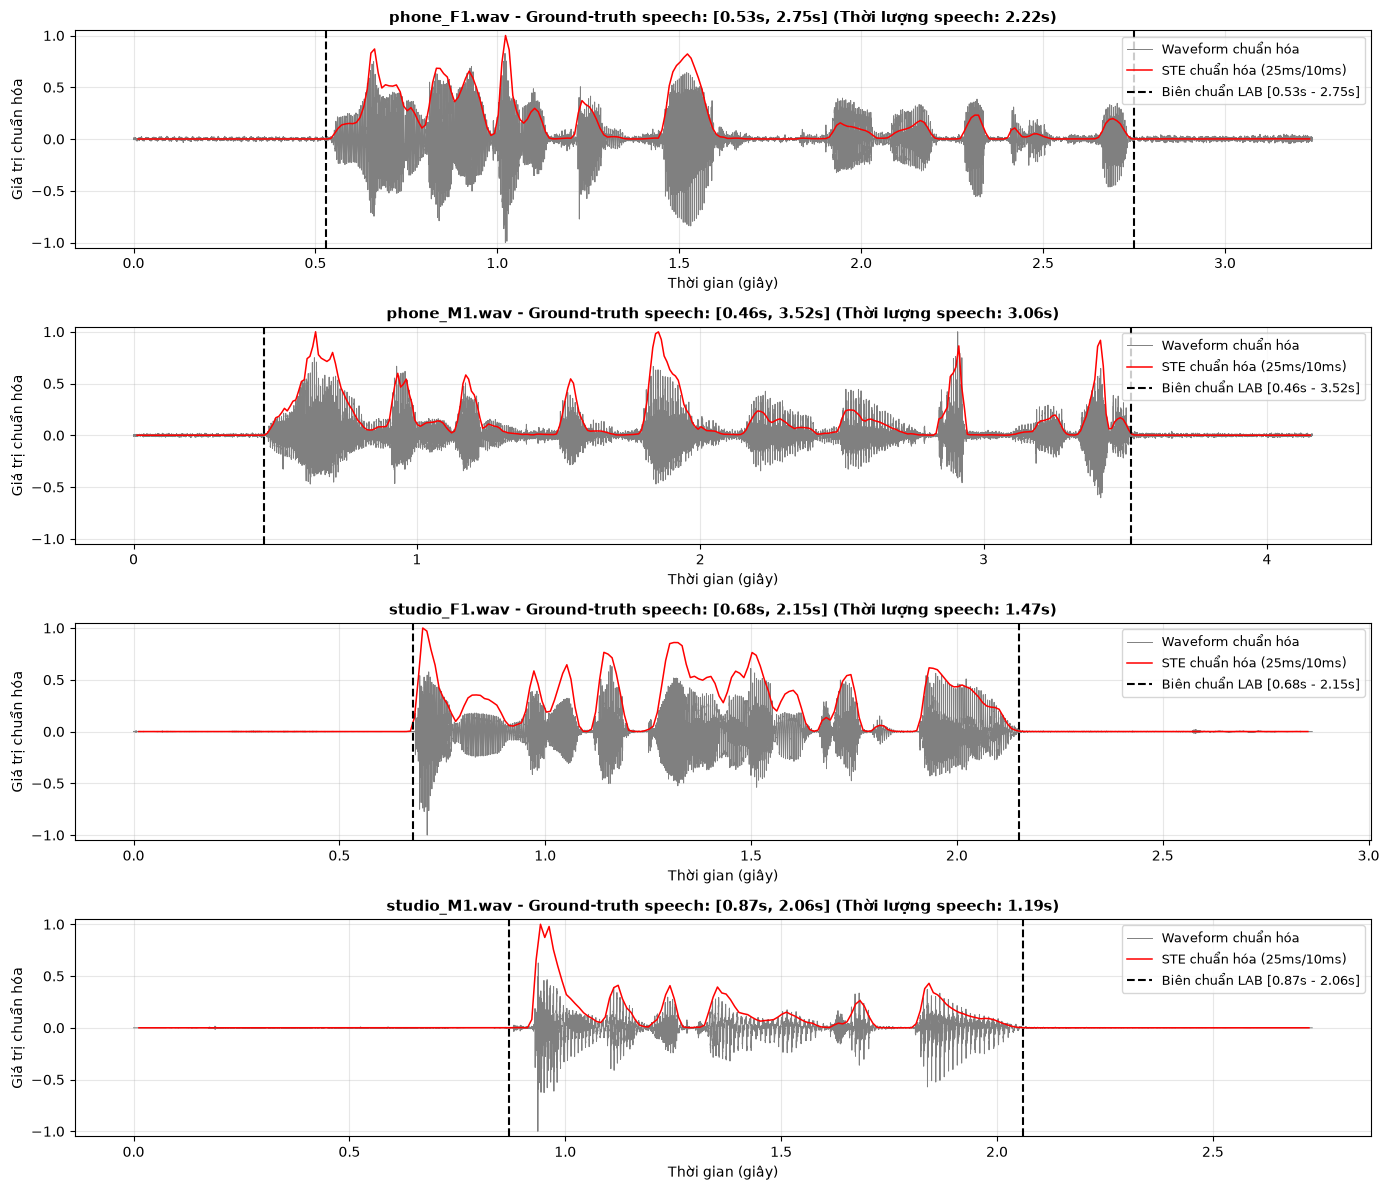

In [8]:
# Cell 4: Đọc dữ liệu đáp số LAB tạo bộ Train, in bảng thống kê chi tiết và vẽ đồ thị

"""Đọc file LAB và trả về danh sách các đoạn (start, end, label)."""
def read_lab_segments(lab_file):
    segments = []
    for line in lab_file.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) != 3:
            continue
        segments.append((float(parts[0]), float(parts[1]), parts[2]))
    return segments


"""Xác định mốc thời gian bắt đầu và kết thúc của toàn bộ vùng tiếng nói (v và uv)."""
def speech_bounds(segments):
    speech_segments = [(start, end) for start, end, label in segments if label in {"v", "uv"}]
    if not speech_segments:
        return (0.0, 0.0)
    return (round(min(start for start, _ in speech_segments), 4),
            round(max(end for _, end in speech_segments), 4))


"""Nạp toàn bộ file WAV, file nhãn LAB, tính STE và lưu trữ có cấu trúc."""
def load_dataset(folder):
    data = {
        "files": [],
        "signals": [],
        "sample_rates": [],
        "durations": [],
        "ste": [],
        "ste_norm": [],
        "frame_starts": [],
        "segments": [],
        "true_bounds": [],
    }

    for wav_file in sorted(folder.glob("*.wav")):
        signal, fs = read_wav(wav_file)
        signal_norm = signal / np.max(np.abs(signal))
        ste, ste_norm, frame_starts = calculate_ste(signal_norm, fs, FRAME_TIME, HOP_TIME)
        lab_file = wav_file.with_suffix(".lab")
        segments = read_lab_segments(lab_file) if lab_file.exists() else []
        bounds = speech_bounds(segments) if segments else (0.0, 0.0)

        data["files"].append(wav_file)
        data["signals"].append(signal_norm)
        data["sample_rates"].append(fs)
        data["durations"].append(len(signal_norm) / fs)
        data["ste"].append(ste)
        data["ste_norm"].append(ste_norm)
        data["frame_starts"].append(frame_starts)
        data["segments"].append(segments)
        data["true_bounds"].append(bounds)

    return data


# Nạp toàn bộ dữ liệu huấn luyện
TRAIN_DATA = load_dataset(TRAIN_DIR)

# In bảng thống kê chi tiết của tập Train
print("=" * 96)
print(f"{'BẢNG THỐNG KÊ CHI TIẾT TẬP HUẤN LUYỆN (TRAINING DATA)':^96}")
print("=" * 96)
header = f"{'File':<16} | {'fs (Hz)':<7} | {'Tổng (s)':<8} | {'Frames':<6} | {'Biên Speech (s)':<17} | {'Speech (s)':<10} | {'Tỉ lệ (%)':<9}"
print(header)
print("-" * 96)

for file, fs, duration, ste_norm, bounds in zip(
    TRAIN_DATA["files"],
    TRAIN_DATA["sample_rates"],
    TRAIN_DATA["durations"],
    TRAIN_DATA["ste_norm"],
    TRAIN_DATA["true_bounds"],
):
    sp_duration = bounds[1] - bounds[0]
    sp_ratio = (sp_duration / duration) * 100.0
    bounds_str = f"[{bounds[0]:.2f}, {bounds[1]:.2f}]"
    print(f"{file.name:<16} | {fs:<7} | {duration:<8.3f} | {len(ste_norm):<6} | {bounds_str:<17} | {sp_duration:<10.3f} | {sp_ratio:<8.2f}%")
print("=" * 96)

# Vẽ đồ thị 4 file huấn luyện kèm vạch biên Ground-truth
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for axis, file, signal, fs, ste_norm, frame_starts, bounds in zip(
    axes,
    TRAIN_DATA["files"],
    TRAIN_DATA["signals"],
    TRAIN_DATA["sample_rates"],
    TRAIN_DATA["ste_norm"],
    TRAIN_DATA["frame_starts"],
    TRAIN_DATA["true_bounds"],
):
    time_signal = np.arange(len(signal)) / fs
    frame_centers = frame_starts + (FRAME_TIME / 2000.0)

    axis.plot(time_signal, signal, color="gray", linewidth=0.7, label="Waveform chuẩn hóa")
    axis.plot(frame_centers, ste_norm, color="red", linewidth=1.1, label="STE chuẩn hóa (25ms/10ms)")
    axis.axvline(bounds[0], color="black", linestyle="--", linewidth=1.5, label=f"Biên chuẩn LAB [{bounds[0]:.2f}s - {bounds[1]:.2f}s]")
    axis.axvline(bounds[1], color="black", linestyle="--", linewidth=1.5)

    axis.set_title(f"{file.name} - Ground-truth speech: [{bounds[0]:.2f}s, {bounds[1]:.2f}s] (Thời lượng speech: {bounds[1]-bounds[0]:.2f}s)", fontsize=11, fontweight="bold")
    axis.set_xlabel("Thời gian (giây)")
    axis.set_ylabel("Giá trị chuẩn hóa")
    axis.set_ylim(-1.05, 1.05)
    axis.grid(alpha=0.3)
    axis.legend(loc="upper right", fontsize=9)

plt.tight_layout()
train_fig_path = OUTPUT_DIR / "train_dataset_overview.png"
plt.savefig(train_fig_path, dpi=150)
print(f"Đã lưu ảnh đồ thị tập huấn luyện vào: {train_fig_path}")
plt.show()


In [9]:
# Cell 5: Các hàm hậu xử lý và đo sai số biên
def remove_short_silence(predictions, hop_ms=HOP_TIME, min_silence_ms=MIN_SILENCE_MS):
    """Lấp các khoảng lặng ngắn hơn min_silence_ms (200 ms) nằm bên trong vùng tiếng nói."""
    result = np.asarray(predictions).copy()
    minimum_frames = int(round(min_silence_ms / hop_ms))
    speech_indexes = np.flatnonzero(result == 1)

    if len(speech_indexes) == 0:
        return result

    index = int(speech_indexes[0])
    last_speech = int(speech_indexes[-1])

    while index <= last_speech:
        if result[index] == 1:
            index += 1
            continue

        start = index
        while index <= last_speech and result[index] == 0:
            index += 1

        if index - start < minimum_frames:
            result[start:index] = 1

    return result


def predictions_to_bounds(predictions, frame_starts, duration, frame_time=FRAME_TIME):
    """Xác định mốc thời gian bắt đầu và kết thúc tiếng nói dựa trên chuỗi nhãn frame."""
    speech_indexes = np.flatnonzero(predictions == 1)

    if len(speech_indexes) == 0:
        return (0.0, 0.0)

    start_time = float(frame_starts[speech_indexes[0]])
    end_time = min(duration, float(frame_starts[speech_indexes[-1]] + frame_time / 1000.0))
    return (round(start_time, 4), round(end_time, 4))


def boundary_metrics(predicted_bounds, true_bounds):
    """Tính sai số biên đầu, sai số biên cuối, MAE (ms) và RMSE (ms)."""
    errors_ms = (np.asarray(predicted_bounds) - np.asarray(true_bounds)) * 1000.0
    mae_ms = float(np.mean(np.abs(errors_ms)))
    rmse_ms = float(np.sqrt(np.mean(errors_ms ** 2)))
    return errors_ms, mae_ms, rmse_ms


In [10]:
# Cell 6: Lớp mô hình tìm kiếm nhị phân ngưỡng năng lượng (EnergyBinarySearchVAD)


class EnergyBinarySearchVAD:
    """
    Mô hình VAD tối ưu hóa ngưỡng Short-Time Energy bằng Binary Search.
    Hàm mục tiêu: triệt tiêu sai lệch tổng thời lượng tiếng nói dự đoán
    so với nhãn ground-truth trên tập huấn luyện.
    """
    def __init__(self, epochs=40, search_range=(1e-4, 0.05)):
        self.epochs = epochs
        self.search_range = search_range
        self.threshold = None
        self.history = []
        self.train_predictions = None
        self.train_bounds = None

    def forward(self, data, threshold=None):
        if threshold is None:
            threshold = self.threshold

        if threshold is None:
            raise ValueError("Mô hình chưa được huấn luyện!")

        all_predictions = []
        all_bounds = []

        for ste_norm, frame_starts, duration in zip(data["ste_norm"], data["frame_starts"], data["durations"]):
            raw_predictions = (ste_norm >= threshold).astype(int)
            processed_predictions = remove_short_silence(raw_predictions, HOP_TIME, MIN_SILENCE_MS)
            bounds = predictions_to_bounds(processed_predictions, frame_starts, duration, FRAME_TIME)
            all_predictions.append(processed_predictions)
            all_bounds.append(bounds)

        return all_predictions, all_bounds

    def loss(self, predicted_bounds, true_bounds):
        signed_duration_errors = []
        boundary_maes = []

        for predicted, truth in zip(predicted_bounds, true_bounds):
            predicted_duration = predicted[1] - predicted[0]
            true_duration = truth[1] - truth[0]
            signed_duration_errors.append(predicted_duration - true_duration)
            _, mae_ms, _ = boundary_metrics(predicted, truth)
            boundary_maes.append(mae_ms)

        return float(np.mean(signed_duration_errors)), float(np.mean(boundary_maes))

    def train(self, data):
        low, high = self.search_range
        self.history = []

        print(f"Bắt đầu tìm kiếm nhị phân ngưỡng STE trên miền [{low:.6f}, {high:.6f}] qua {self.epochs} epochs...")

        for epoch in range(self.epochs):
            threshold = (low + high) / 2.0
            predictions, predicted_bounds = self.forward(data, threshold)
            duration_error, boundary_mae = self.loss(predicted_bounds, data["true_bounds"])

            self.history.append({
                "epoch": epoch + 1,
                "threshold": threshold,
                "duration_error": duration_error,
                "boundary_mae_ms": boundary_mae,
            })

            # In thông tin các bước thu hẹp
            if (epoch + 1) <= 10 or (epoch + 1) % 5 == 0 or (epoch + 1) == self.epochs:
                print(f"Epoch {epoch + 1:02d} | T = {threshold:.8f} | Sai lệch thời lượng = {duration_error:+.4f} s | Train MAE = {boundary_mae:5.2f} ms")

            # Nếu dự đoán speech quá dài -> ngưỡng đang thấp -> nâng cận dưới
            if duration_error > 0:
                low = threshold
            # Nếu dự đoán speech quá ngắn -> ngưỡng đang cao -> hạ cận trên
            else:
                high = threshold

        self.threshold = (low + high) / 2.0
        self.train_predictions, self.train_bounds = self.forward(data)
        return self.history


In [11]:
# Cell 7: Huấn luyện mô hình trên tập Train và in bảng thống kê kết quả huấn luyện
FINAL_MODEL = EnergyBinarySearchVAD(epochs=40)
FINAL_MODEL.train(TRAIN_DATA)

print("\n" + "=" * 85)
print(f">>> NGƯỠNG NĂNG LƯỢNG TỐI ƯU TÌM ĐƯỢC: T = {FINAL_MODEL.threshold:.8f}")
print("=" * 85)

# Đánh giá và in bảng thống kê kết quả trên tập Train
print(f"{'KẾT QUẢ PHÂN ĐOẠN TRÊN TẬP HUẤN LUYỆN (TRAINING EVALUATION)':^85}")
print("-" * 85)
header_train = f"{'File':<16} | {'Biên Ground-truth (s)':<22} | {'Biên Dự đoán (s)':<20} | {'Train MAE (ms)':<15}"
print(header_train)
print("-" * 85)

train_maes = []
for file, truth, pred in zip(TRAIN_DATA["files"], TRAIN_DATA["true_bounds"], FINAL_MODEL.train_bounds):
    _, mae_ms, _ = boundary_metrics(pred, truth)
    train_maes.append(mae_ms)
    t_str = f"[{truth[0]:.2f}, {truth[1]:.2f}]"
    p_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{file.name:<16} | {t_str:<22} | {p_str:<20} | {mae_ms:<15.2f}")

print("-" * 85)
print(f"Train Mean MAE: {np.mean(train_maes):.2f} ms")
print("=" * 85)


Bắt đầu tìm kiếm nhị phân ngưỡng STE trên miền [0.000100, 0.050000] qua 40 epochs...
Epoch 01 | T = 0.02505000 | Sai lệch thời lượng = -0.0200 s | Train MAE = 13.75 ms
Epoch 02 | T = 0.01257500 | Sai lệch thời lượng = -0.0150 s | Train MAE = 11.25 ms
Epoch 03 | T = 0.00633750 | Sai lệch thời lượng = -0.0050 s | Train MAE = 10.00 ms
Epoch 04 | T = 0.00321875 | Sai lệch thời lượng = +0.0000 s | Train MAE = 12.50 ms
Epoch 05 | T = 0.00477813 | Sai lệch thời lượng = -0.0050 s | Train MAE = 10.00 ms
Epoch 06 | T = 0.00399844 | Sai lệch thời lượng = -0.0025 s | Train MAE = 11.25 ms
Epoch 07 | T = 0.00360859 | Sai lệch thời lượng = -0.0025 s | Train MAE = 11.25 ms
Epoch 08 | T = 0.00341367 | Sai lệch thời lượng = +0.0000 s | Train MAE = 12.50 ms
Epoch 09 | T = 0.00351113 | Sai lệch thời lượng = -0.0025 s | Train MAE = 11.25 ms
Epoch 10 | T = 0.00346240 | Sai lệch thời lượng = +0.0000 s | Train MAE = 12.50 ms
Epoch 15 | T = 0.00347915 | Sai lệch thời lượng = -0.0025 s | Train MAE = 11.25 ms
Ep

In [12]:
# Cell 8: Đánh giá mô hình trên tập Kiểm thử (Test Data)
TEST_DATA = load_dataset(TEST_DIR)

# Dự đoán bằng ngưỡng tối ưu đã huấn luyện (không cập nhật ngưỡng)
TEST_PREDICTIONS, TEST_BOUNDS = FINAL_MODEL.forward(TEST_DATA)

TEST_RESULTS = []
for file, predicted, truth in zip(TEST_DATA["files"], TEST_BOUNDS, TEST_DATA["true_bounds"]):
    errors_ms, mae_ms, rmse_ms = boundary_metrics(predicted, truth)
    TEST_RESULTS.append({
        "file": file.name,
        "ground_truth": truth,
        "predicted": predicted,
        "delta_start_ms": float(errors_ms[0]),
        "delta_end_ms": float(errors_ms[1]),
        "mae_ms": mae_ms,
        "rmse_ms": rmse_ms,
    })

print("=" * 96)
print(f"{'BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)':^96}")
print("=" * 96)
header_test = f"{'File':<16} | {'Biên Chuẩn (s)':<16} | {'Biên Đoán (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}"
print(header_test)
print("-" * 96)

for res in TEST_RESULTS:
    gt_str = f"[{res['ground_truth'][0]:.2f}, {res['ground_truth'][1]:.2f}]"
    pr_str = f"[{res['predicted'][0]:.2f}, {res['predicted'][1]:.2f}]"
    d_start_str = f"{res['delta_start_ms']:+.1f} ms"
    d_end_str = f"{res['delta_end_ms']:+.1f} ms"
    print(f"{res['file']:<16} | {gt_str:<16} | {pr_str:<16} | {d_start_str:<10} | {d_end_str:<10} | {res['mae_ms']:<9.2f} | {res['rmse_ms']:<9.2f}")

mean_mae = np.mean([r["mae_ms"] for r in TEST_RESULTS])
mean_rmse = np.mean([r["rmse_ms"] for r in TEST_RESULTS])

print("-" * 96)
print("TỔNG KẾT TẬP KIỂM THỬ:")
print(f"- Mean MAE:  {mean_mae:.2f} ms")
print(f"- Mean RMSE: {mean_rmse:.2f} ms")
print("=" * 96)


                  BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)                  
File             | Biên Chuẩn (s)   | Biên Đoán (s)    | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.01, 4.05]     | -10.0 ms   | +15.0 ms   | 12.50     | 12.75    
phone_M2.wav     | [0.53, 2.52]     | [0.52, 2.52]     | -10.0 ms   | -5.0 ms    | 7.50      | 7.91     
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.35]     | -10.0 ms   | -15.0 ms   | 12.50     | 12.75    
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.94]     | +10.0 ms   | +5.0 ms    | 7.50      | 7.91     
------------------------------------------------------------------------------------------------
TỔNG KẾT TẬP KIỂM THỬ:
- Mean MAE:  10.00 ms
- Mean RMSE: 10.33 ms


Đã xuất và lưu toàn bộ 4 ảnh test riêng lẻ và ảnh tổng hợp vào: D:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT1\output\mine


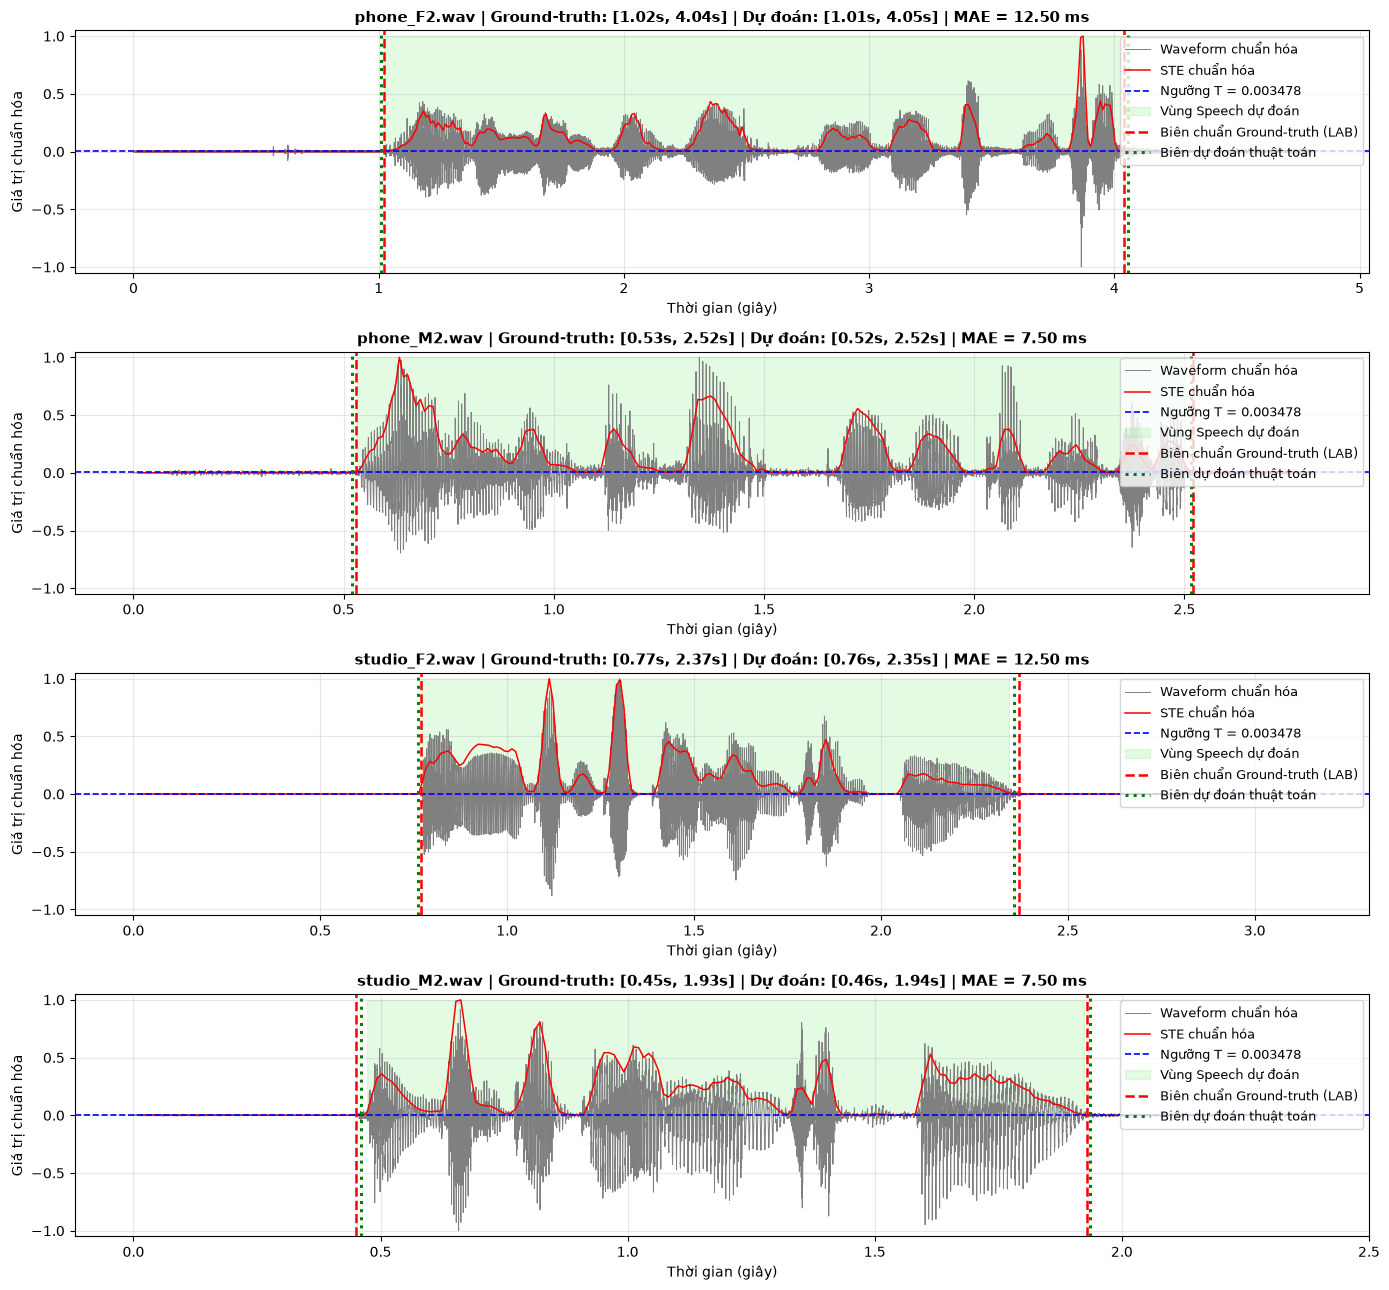

In [13]:
# Cell 9: Vẽ và lưu ảnh đồ thị kết quả trên tập kiểm thử (Test Data)
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=False)

for axis, file, signal, fs, ste_norm, frame_starts, predictions, result in zip(
    axes,
    TEST_DATA["files"],
    TEST_DATA["signals"],
    TEST_DATA["sample_rates"],
    TEST_DATA["ste_norm"],
    TEST_DATA["frame_starts"],
    TEST_PREDICTIONS,
    TEST_RESULTS,
):
    time_signal = np.arange(len(signal)) / fs
    frame_centers = frame_starts + (FRAME_TIME / 2000.0)

    # Vẽ waveform và STE
    axis.plot(time_signal, signal, color="gray", linewidth=0.7, label="Waveform chuẩn hóa")
    axis.plot(frame_centers, ste_norm, color="red", linewidth=1.1, label="STE chuẩn hóa")
    axis.axhline(FINAL_MODEL.threshold, color="blue", linestyle="--", linewidth=1.2, label=f"Ngưỡng T = {FINAL_MODEL.threshold:.6f}")

    # Tô màu vùng tiếng nói được phát hiện
    axis.fill_between(frame_centers, 0, 1, where=predictions == 1, color="lightgreen", alpha=0.25, label="Vùng Speech dự đoán")

    # Vẽ các đường biên
    true_start, true_end = result["ground_truth"]
    pred_start, pred_end = result["predicted"]

    axis.axvline(true_start, color="red", linestyle="--", linewidth=1.8, label="Biên chuẩn Ground-truth (LAB)")
    axis.axvline(true_end, color="red", linestyle="--", linewidth=1.8)
    axis.axvline(pred_start, color="green", linestyle=":", linewidth=2.2, label="Biên dự đoán thuật toán")
    axis.axvline(pred_end, color="green", linestyle=":", linewidth=2.2)

    # Tiêu đề và nhãn
    axis.set_title(f"{file.name} | Ground-truth: [{true_start:.2f}s, {true_end:.2f}s] | Dự đoán: [{pred_start:.2f}s, {pred_end:.2f}s] | MAE = {result['mae_ms']:.2f} ms", fontsize=11, fontweight="bold")
    axis.set_xlabel("Thời gian (giây)")
    axis.set_ylabel("Giá trị chuẩn hóa")
    axis.set_ylim(-1.05, 1.05)
    axis.grid(alpha=0.3)
    axis.legend(loc="upper right", fontsize=9)

    # Lưu hình ảnh từng file riêng biệt
    single_fig, single_ax = plt.subplots(figsize=(12, 4))
    single_ax.plot(time_signal, signal, color="gray", linewidth=0.7, label="Waveform chuẩn hóa")
    single_ax.plot(frame_centers, ste_norm, color="red", linewidth=1.1, label="STE chuẩn hóa")
    single_ax.axhline(FINAL_MODEL.threshold, color="blue", linestyle="--", label=f"T = {FINAL_MODEL.threshold:.6f}")
    single_ax.fill_between(frame_centers, 0, 1, where=predictions == 1, color="lightgreen", alpha=0.25, label="Speech dự đoán")
    single_ax.axvline(true_start, color="red", linestyle="--", linewidth=1.8, label="Biên chuẩn Ground-truth")
    single_ax.axvline(true_end, color="red", linestyle="--", linewidth=1.8)
    single_ax.axvline(pred_start, color="green", linestyle=":", linewidth=2.2, label="Biên dự đoán")
    single_ax.axvline(pred_end, color="green", linestyle=":", linewidth=2.2)
    single_ax.set_title(f"{file.name} (Boundary MAE: {result['mae_ms']:.2f} ms)", fontsize=12, fontweight="bold")
    single_ax.set_xlabel("Thời gian (giây)")
    single_ax.set_ylabel("Biên độ chuẩn hóa")
    single_ax.set_ylim(-1.05, 1.05)
    single_ax.grid(alpha=0.3)
    single_ax.legend(loc="upper right", fontsize=8)
    single_fig.tight_layout()
    single_path = OUTPUT_DIR / f"{file.stem}.png"
    single_fig.savefig(single_path, dpi=150)
    plt.close(single_fig)

plt.tight_layout()
summary_fig_path = OUTPUT_DIR / "test_summary.png"
plt.savefig(summary_fig_path, dpi=150)
print(f"Đã xuất và lưu toàn bộ 4 ảnh test riêng lẻ và ảnh tổng hợp vào: {OUTPUT_DIR.resolve()}")
plt.show()
